# Geometry in the neural processing of phoneme sequences

Figures for the paper. Analyses live in `intervention.state_analysis.geometry`, figures in
`intervention.plotting.plots`, and the artifacts they read are built by
`intervention.reproduce`.

`ensure_all()` builds whatever is missing and skips whatever is already on disk. The `runs`
step is the slow one; from a cold checkout prefer the shell, which parallelises over
configs:

```bash
python -m intervention.reproduce --n_jobs 6
```

In [1]:
import pandas as pd

from intervention.paths import STATES_DIR
from intervention.plotting import plots as P
from intervention.reproduce import ensure_all, summary_table
from intervention.state_analysis import geometry as G
from intervention.state_analysis.states_extract import StatesDataset

P.paper_style()

In [2]:
paper = ensure_all()
summary_table().round(4)

[states] up to date: train_states, test_states
[runs] up to date: 6 configs under /Users/nafis/Work/spiral_representation/results/paper
[random baseline] up to date: /Users/nafis/Work/spiral_representation/plots/random_baseline/profiles.csv
[surprisal] up to date: /Users/nafis/Work/spiral_representation/plots/surprisal/regression.csv


,model,embedding,n_seeds,test_acc_mean,test_acc_std,run_name
0,low_rank-8,fixed,4,0.6426,0.0179,source-modified-min3-low_rank-8-state_concat-i...
1,low_rank-8,learned,4,0.7566,0.0156,source-modified-min3-low_rank-8-state_concat-i...
2,onion,fixed,4,0.5716,0.0076,source-modified-min3-onion-state_concat-init_d...
3,onion,learned,4,0.6313,0.0077,source-modified-min3-onion-state_concat-init_d...
4,spiral_rope,fixed,4,0.6244,0.0076,source-modified-min3-spiral_rope-state_concat-...
5,spiral_rope,learned,4,0.7226,0.0060,source-modified-min3-spiral_rope-state_concat-...


## Figure 1 — state geometry

In [3]:
states = StatesDataset.load(str(STATES_DIR / "train_states"))
vowels, consonants = G.phoneme_categories()
print(f"{len(states):,} tokens from {states.metadata['seq_id'].nunique():,} words")

217,229 tokens from 30,000 words


### 1A — ‖Δz‖ by position

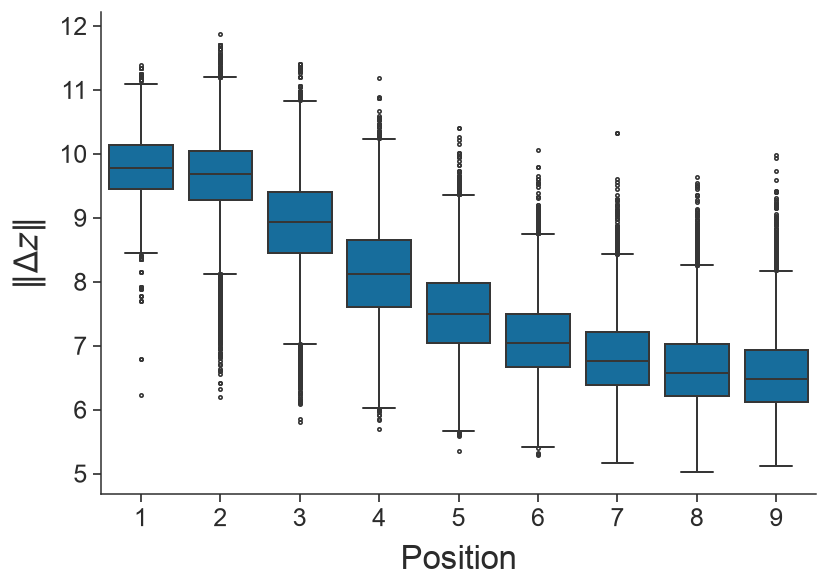

In [4]:
P.norm_by_position(G.norm_table(states), fig_size=(7, 5));

### 1B — Δz cosine similarity by phoneme category

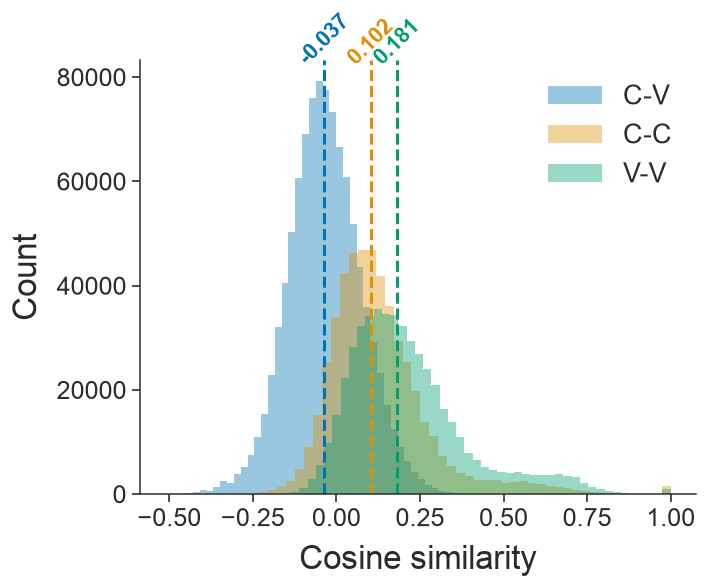

In [5]:
similarities = {
    "C-V": G.category_similarity(states, consonants, vowels),
    "C-C": G.category_similarity(states, consonants, consonants),
    "V-V": G.category_similarity(states, vowels, vowels),
}
P.similarity_histogram(similarities, fig_size=(6, 5));

### 1C — Δz cosine similarity by position, same vs different phoneme

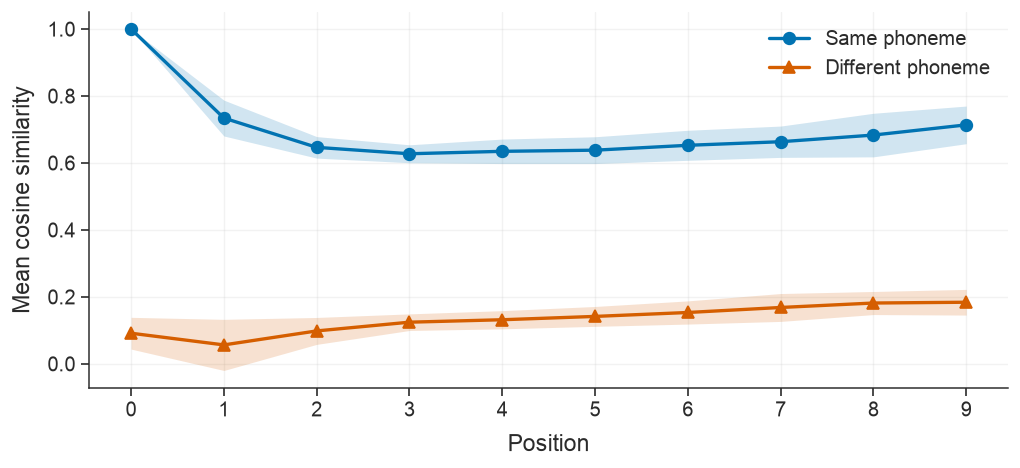

In [6]:
P.similarity_by_position(G.similarity_by_position(states));

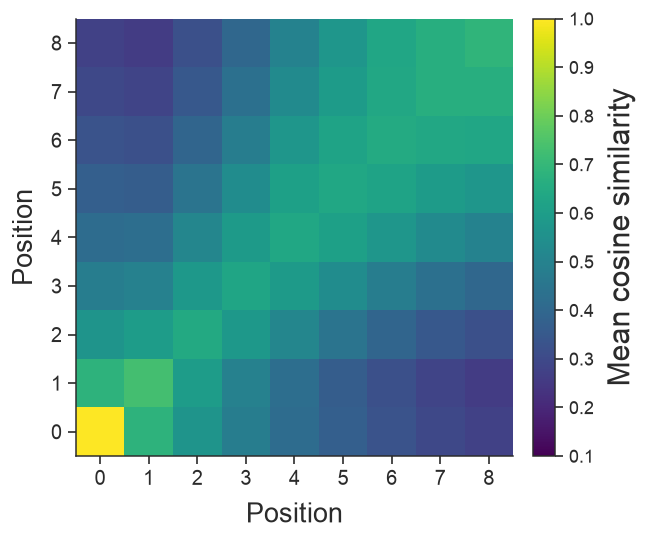

In [4]:
same, different = G.position_similarity_matrix(states)
# low, high = min(same.min().min(), different.min().min()), max(same.max().max(), different.max().max())

P.position_similarity_matrix(same, title="", vmin=0.1, vmax=1.0, max_pos=8);
# P.position_similarity_matrix(different, title="Different phoneme", vmin=0.0, vmax=1.0, max_pos=9);


In [ ]:
# pca of delta state colored by phoneme type consonant (yellow) vs vowel (blue)

## Figure 2 — intervention

`onion`, `spiral_rope` and `low_rank-8`, each with the identity embedding learned and
fixed, over 4 CV seeds.

In [ ]:
runs = P.load_runs(paper.results_dir, names=list(paper.runs))
main = [r for r in runs.values() if r.model in ("onion", "spiral_rope")]
list(runs.values())

[CVRun(onion, learned, n_seeds=4),
 CVRun(onion, fixed, n_seeds=4),
 CVRun(spiral, learned, n_seeds=4),
 CVRun(spiral, fixed, n_seeds=4),
 CVRun(low rank (r=8), learned, n_seeds=4),
 CVRun(low rank (r=8), fixed, n_seeds=4)]

### 2A — accuracy by edit position

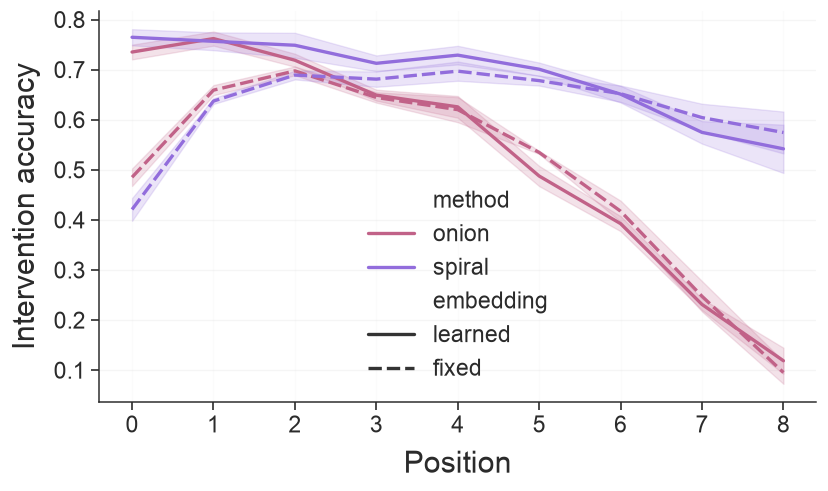

In [ ]:
P.accuracy_by_position(main, fig_size=(7, 4.2));

### 2B — accuracy by method and embedding

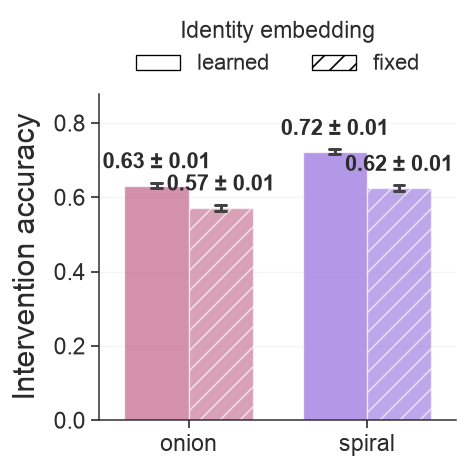

In [ ]:
P.accuracy_bars(main, fig_size=(4,4));

### 2C — spiral: effective scale vectors in PCA space

`params.npz["scales"]` is the effective scale — the rotation is already applied.

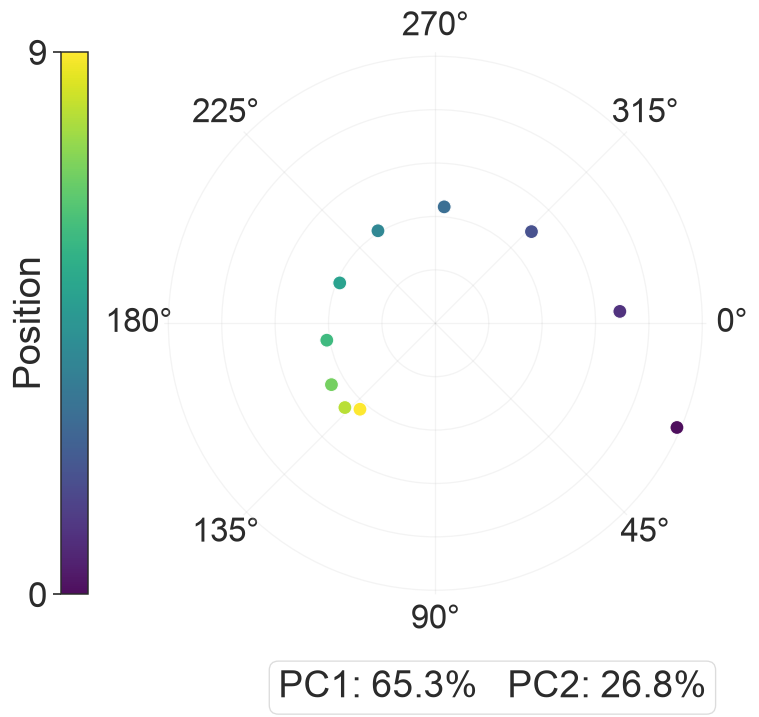

In [ ]:
spiral = next(r for r in runs.values() if r.model == "spiral_rope" and r.embedding == "learned")
P.scale_pca(spiral.scales,polar=True, title="");

## Appendix

###  low rank (r=8): effective scale vectors in polar coordinates

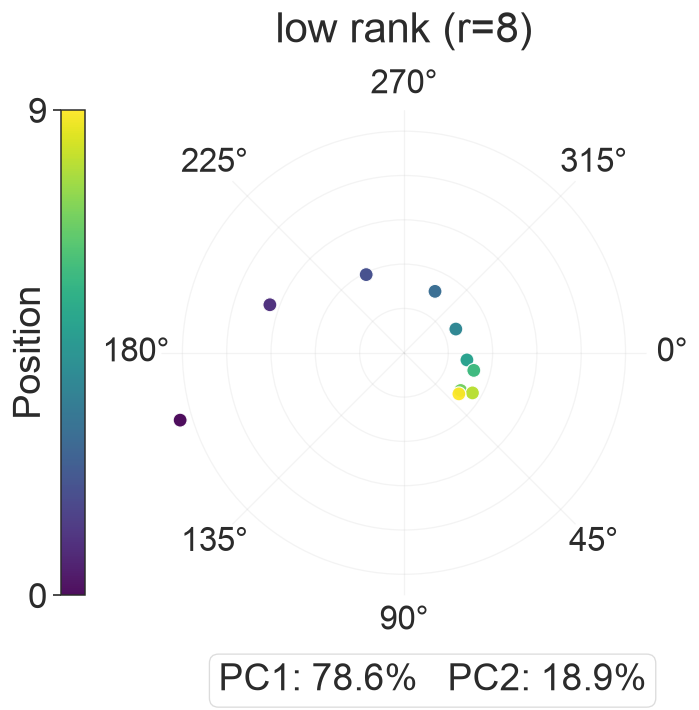

In [ ]:
low_rank = next(r for r in runs.values() if r.model == "low_rank-8" and r.embedding == "learned")
P.scale_pca(low_rank.scales, polar=True, title="low rank (r=8)");

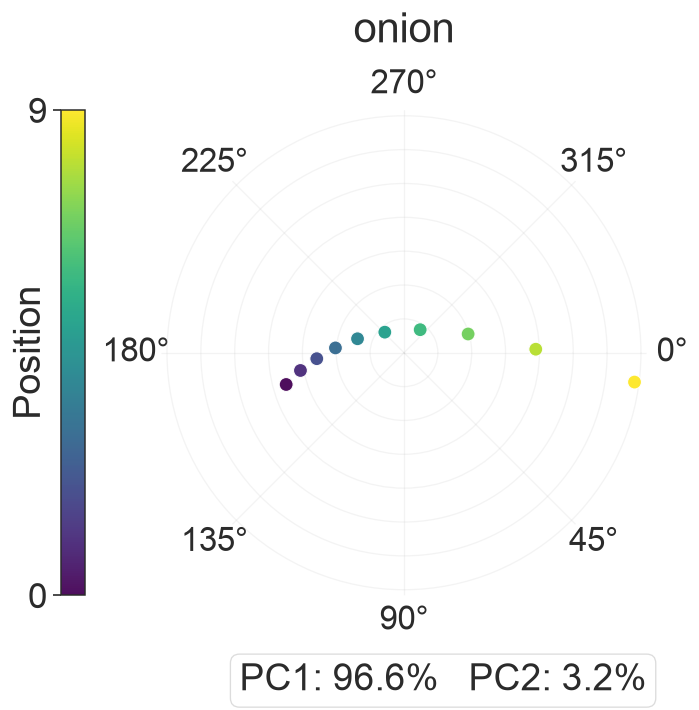

In [ ]:
onion = next(r for r in runs.values() if r.model == "onion" and r.embedding == "learned")
P.scale_pca(onion.scales, polar=True, title="onion");

###  scale vector angle to position 0

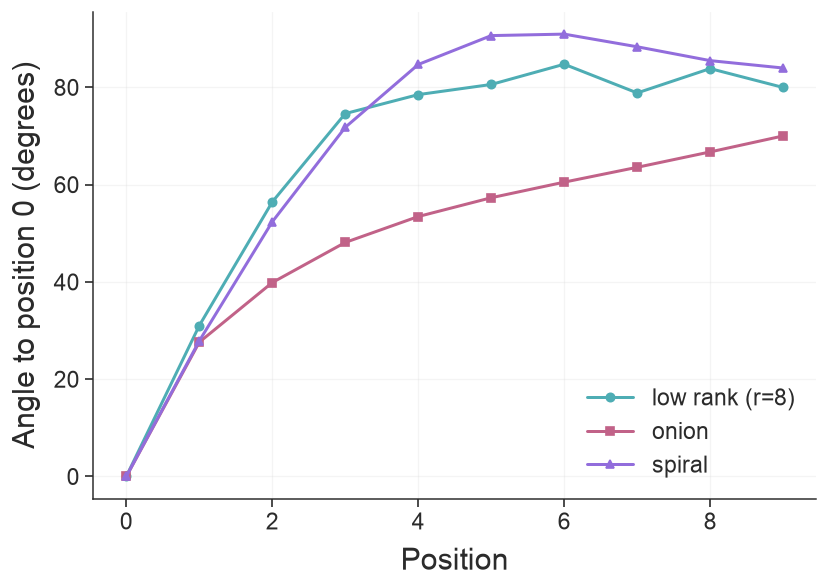

In [ ]:
angles = {r.label: G.angles_to_first(r.scales)
          for r in sorted(runs.values(), key=lambda r: r.label) if r.embedding == "learned"}
P.angle_by_position(angles);

###  intrinsic dimension by position

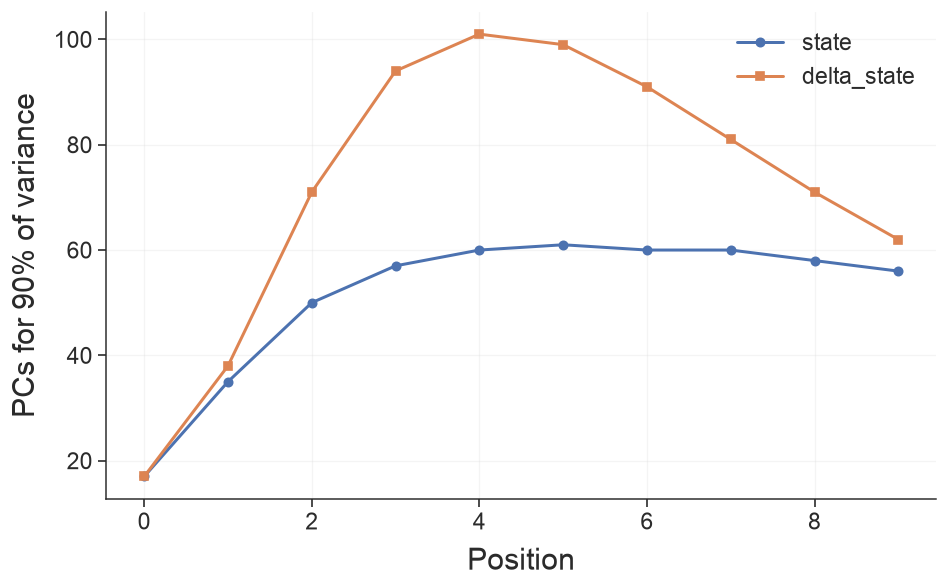

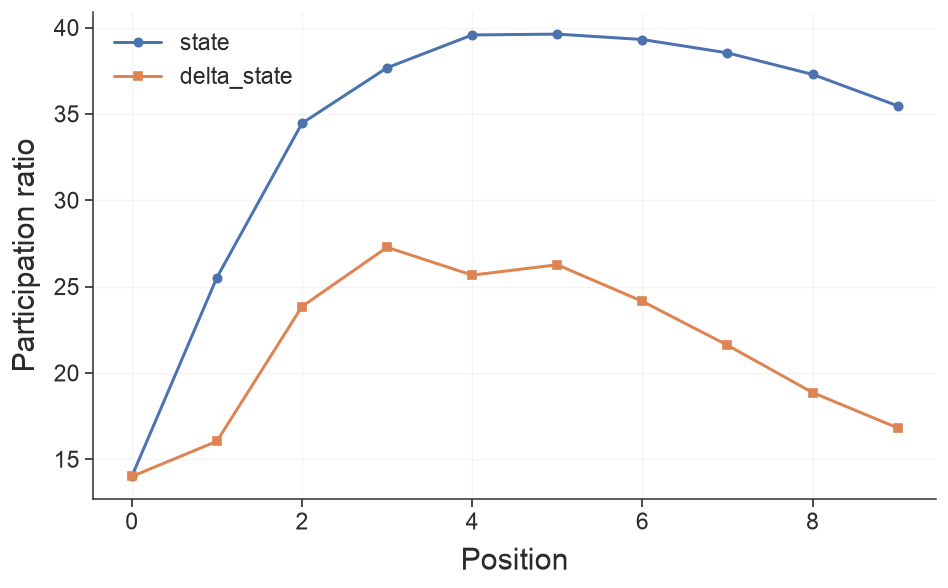

In [ ]:
dimensions = G.dimension_by_position(states)
P.dimension_by_position(dimensions, metric="d90")
P.dimension_by_position(dimensions, metric="participation_ratio");

###  control: trained vs randomly initialised encoder

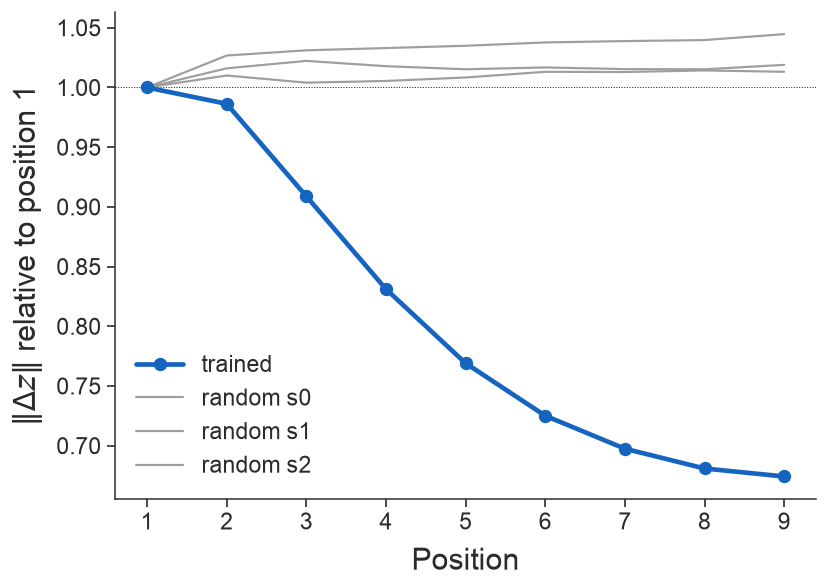

In [ ]:
P.random_baseline(pd.read_csv(paper.baseline), rescale=True);

###  control: ‖Δz‖ ~ position + surprisal

In [ ]:
regression = pd.read_csv(paper.surprisal)
(regression[regression["model"] == "Position + surprisal"]
 [["surprisal", "term", "beta", "ci_low", "ci_high", "unique_r2", "r2"]]
 .round(4).reset_index(drop=True))

,surprisal,term,beta,ci_low,ci_high,unique_r2,r2
0,s_bigram,position,-0.7740,-0.7782,-0.7697,0.5365,0.7115
1,s_bigram,surprisal,0.1683,0.1654,0.1711,0.0254,0.7115
2,s_cohort,position,-0.6487,-0.6535,-0.6438,0.2358,0.7272
3,s_cohort,surprisal,0.2709,0.2674,0.2744,0.0411,0.7272


###  per-run diagnostics

Training curves, learned embedding, and accuracy by lexical factor, written next to each
run's artifacts:

```bash
python -m intervention.plotting.plots results/paper
```